(2509, 34)
Patient ID                          0
Age at Diagnosis                   11
Type of Breast Surgery            554
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                       592
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
Cohort                             11
ER status measured by IHC          83
ER Status                          40
Neoplasm Histologic Grade         121
HER2 status measured by SNP6      529
HER2 Status                       529
Tumor Other Histologic Subtype    135
Hormone Therapy                   529
Inferred Menopausal State         529
Integrative Cluster               529
Primary Tumor Laterality          639
Lymph nodes examined positive     266
Mutation Count                    152
Nottingham prognostic index       222
Oncotree Code                       0
Overall Survival (Months)         528
Overall Survival Status           528
PR Status                         529
R

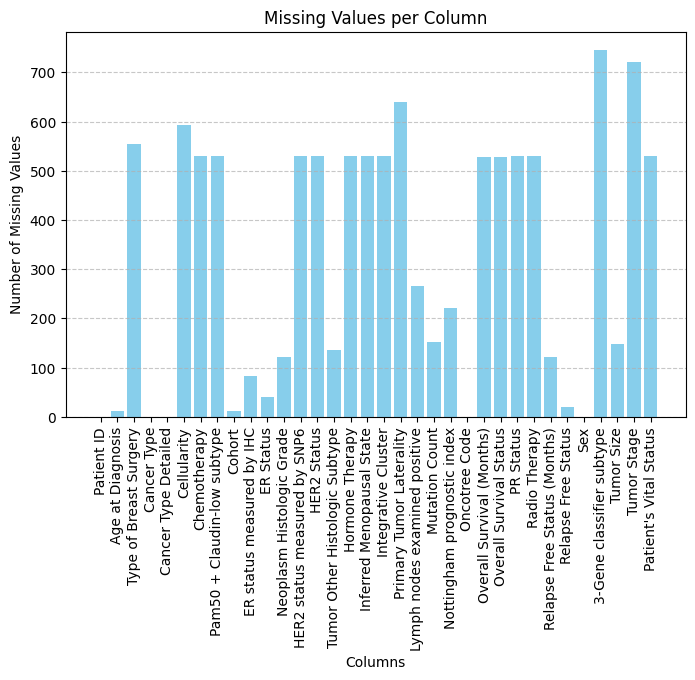

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Breast_Cancer_METABRIC.csv")

df.head()

print(df.shape)
df = df.fillna(np.nan)
missing_counts = df.isnull().sum()

print(missing_counts)

plt.figure(figsize=(8, 5))
plt.bar(missing_counts.index, missing_counts.values, color='skyblue')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

(2509, 60)
Age at Diagnosis                                                   11
Chemotherapy                                                      529
Cohort                                                             11
ER status measured by IHC                                          83
ER Status                                                          40
Neoplasm Histologic Grade                                         121
HER2 Status                                                       529
Hormone Therapy                                                   529
Inferred Menopausal State                                         529
Primary Tumor Laterality                                          639
Lymph nodes examined positive                                     266
Mutation Count                                                    152
Nottingham prognostic index                                       222
Overall Survival Status                                           528
PR Status

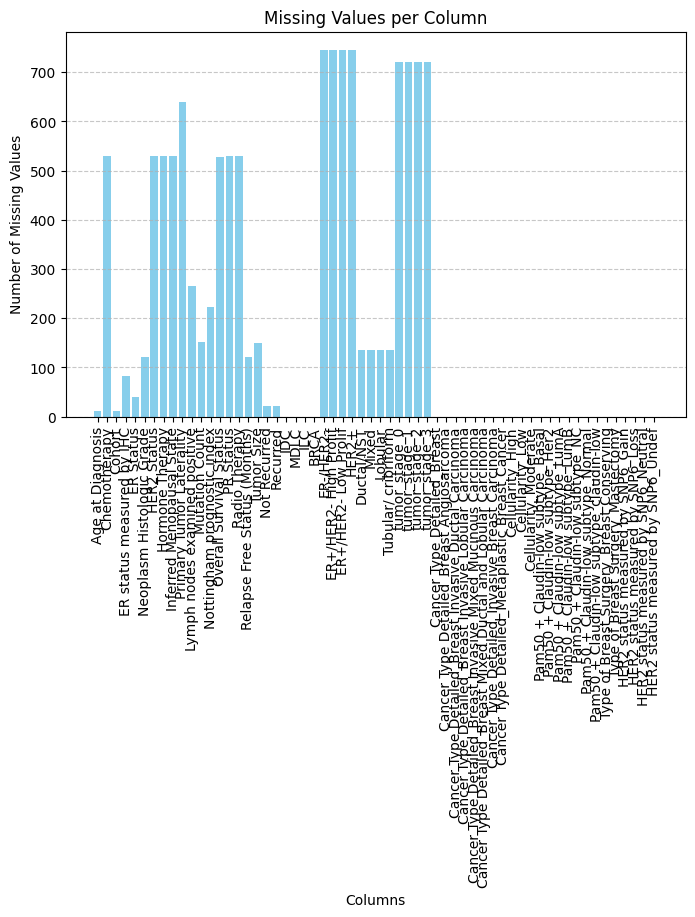

In [58]:
df = df.drop(["Cancer Type","Patient ID","Integrative Cluster","Overall Survival (Months)","Patient's Vital Status","Sex"],axis=1)

def encode_Relapse_Free_Statu(Relapse):
    return {
        'Not Recurred': 1 if Relapse == 'Not Recurred' else (np.nan if pd.isna(Relapse) else 0),
        'Recurred': 1 if Relapse == 'Recurred' else (np.nan if pd.isna(Relapse) else 0)
    }

def encode_Oncotree_Code(oncotree):
    return{
        'IDC': 1 if oncotree == 'IDC' else (np.nan if pd.isna(oncotree) else 0),
        'MDLC': 1 if oncotree == 'MDLC' else (np.nan if pd.isna(oncotree) else 0),
        'ILC': 1 if oncotree == 'ILC' else (np.nan if pd.isna(oncotree) else 0),
        'BRCA': 1 if oncotree == 'BRCA' else (np.nan if pd.isna(oncotree) else 0)
    }

def encode_Tumor_Other_Histologic_Subtype(subtype):
    return{
        'Ductal/NST': 1 if subtype == 'Ductal/NST' else (np.nan if pd.isna(subtype) else 0),
        'Mixed': 1 if subtype == 'Mixed' else (np.nan if pd.isna(subtype) else 0),
        'Lobular': 1 if subtype == 'Lobular' else (np.nan if pd.isna(subtype) else 0),
        'Tubular/ cribriform': 1 if subtype == 'Tubular/ cribriform' else (np.nan if pd.isna(subtype) else 0)
    }

def encode_3_Gene_classifier_subtype(subtype):
    return{
        'ER-/HER2-': 1 if subtype == 'ER-/HER2-' else (np.nan if pd.isna(subtype) else 0),
        'ER+/HER2- High Prolif': 1 if subtype == 'ER+/HER2- High Prolif' else (np.nan if pd.isna(subtype) else 0),
        'ER+/HER2- Low Prolif': 1 if subtype == 'ER+/HER2- Low Prolif' else (np.nan if pd.isna(subtype) else 0),
        'HER2+': 1 if subtype == 'HER2+' else (np.nan if pd.isna(subtype) else 0)
    }

def encode_tumor_stage(stage):
    return{
        'tumor_stage_0': 1 if stage == 0 else (np.nan if pd.isna(stage) else 0),
        'tumor_stage_1': 1 if stage == 1 else (np.nan if pd.isna(stage) else 0),
        'tumor_stage_2': 1 if stage == 2 else (np.nan if pd.isna(stage) else 0),
        'tumor_stage_3': 1 if stage == 3 else (np.nan if pd.isna(stage) else 0)
    }

encode_Relapse_Free_Status = df['Relapse Free Status'].apply(lambda x: pd.Series(encode_Relapse_Free_Statu(x)))

encode_tumor_stage_Status = df['Tumor Stage'].apply(lambda x: pd.Series(encode_tumor_stage(x)))

encode_3_Gene_classifier_subtype_Status = df['3-Gene classifier subtype'].apply(lambda x: pd.Series(encode_3_Gene_classifier_subtype(x)))

encode_Oncotree_Code_Status = df['Oncotree Code'].apply(lambda x: pd.Series(encode_Oncotree_Code(x)))

encode_Tumor_Other_Histologic_Subtype_Status = df['Tumor Other Histologic Subtype'].apply(lambda x: pd.Series(encode_Tumor_Other_Histologic_Subtype(x)))

df = pd.concat([df, encode_Relapse_Free_Status], axis=1)
df = pd.concat([df, encode_Oncotree_Code_Status], axis=1)
df = pd.concat([df, encode_3_Gene_classifier_subtype_Status], axis=1)
df = pd.concat([df, encode_Tumor_Other_Histologic_Subtype_Status], axis=1)
df = pd.concat([df, encode_tumor_stage_Status], axis=1)

df = df.drop(["Oncotree Code","Tumor Other Histologic Subtype","Relapse Free Status","3-Gene classifier subtype","Tumor Stage"],axis=1)

df.loc[df['PR Status']=='Positive', 'PR Status'] = 1
df.loc[df['PR Status']=='Negative', 'PR Status'] = 0

df.loc[df['ER Status']=='Positive', 'ER Status'] = 1
df.loc[df['ER Status']=='Negative', 'ER Status'] = 0

df.loc[df['ER status measured by IHC']=='Positve', 'ER status measured by IHC'] = 1
df.loc[df['ER status measured by IHC']=='Negative', 'ER status measured by IHC'] = 0

df.loc[df['Radio Therapy']=='Yes', 'Radio Therapy'] = 1
df.loc[df['Radio Therapy']=='No', 'Radio Therapy'] = 0

df.loc[df['Chemotherapy']=='Yes', 'Chemotherapy'] = 1
df.loc[df['Chemotherapy']=='No', 'Chemotherapy'] = 0

df.loc[df['Overall Survival Status']=='Living', 'Overall Survival Status'] = 1
df.loc[df['Overall Survival Status']=='Deceased', 'Overall Survival Status'] = 0

df.loc[df['Primary Tumor Laterality']=='Right', 'Primary Tumor Laterality'] = 1
df.loc[df['Primary Tumor Laterality']=='Left', 'Primary Tumor Laterality'] = 0

df.loc[df['Inferred Menopausal State']=='Pre', 'Inferred Menopausal State'] = 1
df.loc[df['Inferred Menopausal State']=='Post', 'Inferred Menopausal State'] = 0

df.loc[df['Hormone Therapy']=='Yes', 'Hormone Therapy'] = 1
df.loc[df['Hormone Therapy']=='No', 'Hormone Therapy'] = 0

df.loc[df['HER2 Status']=='Positive', 'HER2 Status'] = 1
df.loc[df['HER2 Status']=='Negative', 'HER2 Status'] = 0

dummies = pd.get_dummies(df, columns=['Cancer Type Detailed','Cellularity','Pam50 + Claudin-low subtype','Type of Breast Surgery','HER2 status measured by SNP6'],dtype=int)

df = pd.concat([df, dummies], axis=1)

df = df.drop(['Cancer Type Detailed','Cellularity','Pam50 + Claudin-low subtype','Type of Breast Surgery','HER2 status measured by SNP6'],axis=1)
df = df.loc[:, ~df.columns.duplicated()]
df.loc[df['Age at Diagnosis'].notna(), 'Age at Diagnosis'] = df.loc[df['Age at Diagnosis'].notna(), 'Age at Diagnosis'].astype(int)

print(df.shape)
missing_counts = df.isnull().sum()

print(missing_counts)

plt.figure(figsize=(8, 5))
plt.bar(missing_counts.index, missing_counts.values, color='skyblue')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [59]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

features = ['Cancer Type Detailed_Breast', 'Cancer Type Detailed_Breast Angiosarcoma',
            'Cancer Type Detailed_Breast Invasive Ductal Carcinoma','Cancer Type Detailed_Breast Invasive Lobular Carcinoma',
            'Cancer Type Detailed_Breast Invasive Mixed Mucinous Carcinoma','Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma',
            'Cancer Type Detailed_Invasive Breast Carcinoma','Cancer Type Detailed_Metaplastic Breast Cancer',
            'Cellularity_High','Cellularity_Low','Cellularity_Moderate','Pam50 + Claudin-low subtype_Basal',
            'Pam50 + Claudin-low subtype_Her2','Pam50 + Claudin-low subtype_LumA','Pam50 + Claudin-low subtype_LumB',
            'Pam50 + Claudin-low subtype_NC','Pam50 + Claudin-low subtype_Normal','Pam50 + Claudin-low subtype_claudin-low',
            'Type of Breast Surgery_Breast Conserving','Type of Breast Surgery_Mastectomy','HER2 status measured by SNP6_Gain',
            'HER2 status measured by SNP6_Loss','HER2 status measured by SNP6_Neutral','HER2 status measured by SNP6_Undef']

train_df = df[df['Chemotherapy'].notna()]
test_df = df[df['Chemotherapy'].isna()]

X_train = train_df[features]
y_train = train_df['Chemotherapy'].astype(int)

X_test = test_df[features]

model = LogisticRegressionCV(random_state=0,cv=7)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_chemo = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['ER-/HER2-'].notna()]
test_df = df[df['ER-/HER2-'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['ER-/HER2-'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_ER_HER2 = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['ER+/HER2- High Prolif'].notna()]
test_df = df[df['ER+/HER2- High Prolif'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['ER+/HER2- High Prolif'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_ER_HER2_High_Prolif = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['ER+/HER2- Low Prolif'].notna()]
test_df = df[df['ER+/HER2- Low Prolif'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['ER+/HER2- Low Prolif'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_ER_HER2_Low_Prolif = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['HER2+'].notna()]
test_df = df[df['HER2+'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['HER2+'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_HER2__ = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['Ductal/NST'].notna()]
test_df = df[df['Ductal/NST'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['Ductal/NST'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_Ductal = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['Mixed'].notna()]
test_df = df[df['Mixed'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['Mixed'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_Mixed = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['Lobular'].notna()]
test_df = df[df['Lobular'].isna()]
X_train = train_df[features]

X_test = test_df[features]
y_train = train_df['Lobular'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_Lobular = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['Tubular/ cribriform'].notna()]
test_df = df[df['Tubular/ cribriform'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['Tubular/ cribriform'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_Tubular = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['Primary Tumor Laterality'].notna()]
test_df = df[df['Primary Tumor Laterality'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['Primary Tumor Laterality'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_Primary_Tumor_Laterality = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
train_df = df[df['PR Status'].notna()]
test_df = df[df['PR Status'].isna()]
X_train = train_df[features]
X_test = test_df[features]
y_train = train_df['PR Status'].astype(int)
x_train_val , x_test_val, y_train_val, y_test_val = train_test_split(X_train,y_train,train_size=0.8,random_state=0)
model.fit(x_train_val, y_train_val)
y_pred_train = model.predict(x_test_val)
score = accuracy_score(y_test_val, y_pred_train)
print(score)
y_pred_PR_Status = model.predict(X_test)
#-----------------------------------------------------------------------------------------------------------------------
df.loc[df['Chemotherapy'].isna(), 'Chemotherapy'] = y_pred_chemo
df.loc[df['ER-/HER2-'].isna(), 'ER-/HER2-'] = y_pred_ER_HER2
df.loc[df['ER+/HER2- High Prolif'].isna(), 'ER+/HER2- High Prolif'] = y_pred_ER_HER2_High_Prolif
df.loc[df['ER+/HER2- Low Prolif'].isna(), 'ER+/HER2- Low Prolif'] = y_pred_ER_HER2_Low_Prolif
df.loc[df['HER2+'].isna(), 'HER2+'] = y_pred_HER2__
df.loc[df['PR Status'].isna(), 'PR Status'] = y_pred_PR_Status
df.loc[df['Ductal/NST'].isna(), 'Ductal/NST'] = y_pred_Ductal
df.loc[df['Mixed'].isna(), 'Mixed'] = y_pred_Mixed
df.loc[df['Lobular'].isna(), 'Lobular'] = y_pred_Lobular
df.loc[df['Tubular/ cribriform'].isna(), 'Tubular/ cribriform'] = y_pred_Tubular
df.loc[df['Primary Tumor Laterality'].isna(), 'Primary Tumor Laterality'] = y_pred_Primary_Tumor_Laterality


0.797979797979798
0.9235127478753541
0.8158640226628895
0.8045325779036827
0.9320113314447592
0.9873684210526316
1.0
1.0
0.9936842105263158
0.4893048128342246
0.7323232323232324


Age at Diagnosis                                                   11
Chemotherapy                                                        0
Cohort                                                             11
ER status measured by IHC                                          83
ER Status                                                          40
Neoplasm Histologic Grade                                         121
HER2 Status                                                       529
Hormone Therapy                                                   529
Inferred Menopausal State                                         529
Primary Tumor Laterality                                            0
Lymph nodes examined positive                                     266
Mutation Count                                                    152
Nottingham prognostic index                                       222
Overall Survival Status                                           528
PR Status           

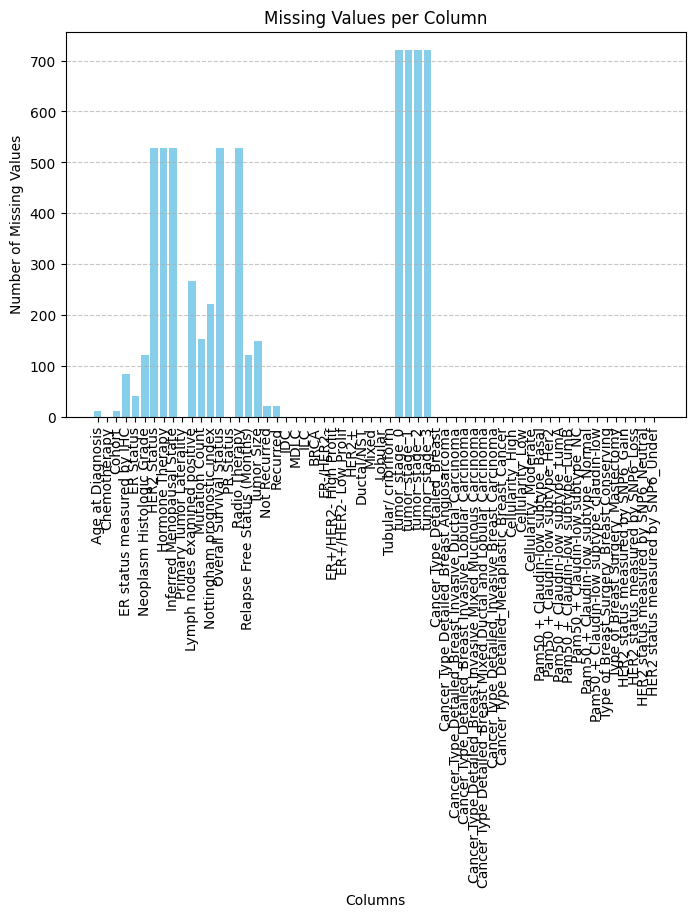

In [60]:
missing_counts = df.isnull().sum()

print(missing_counts)

plt.figure(figsize=(8, 5))
plt.bar(missing_counts.index, missing_counts.values, color='skyblue')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

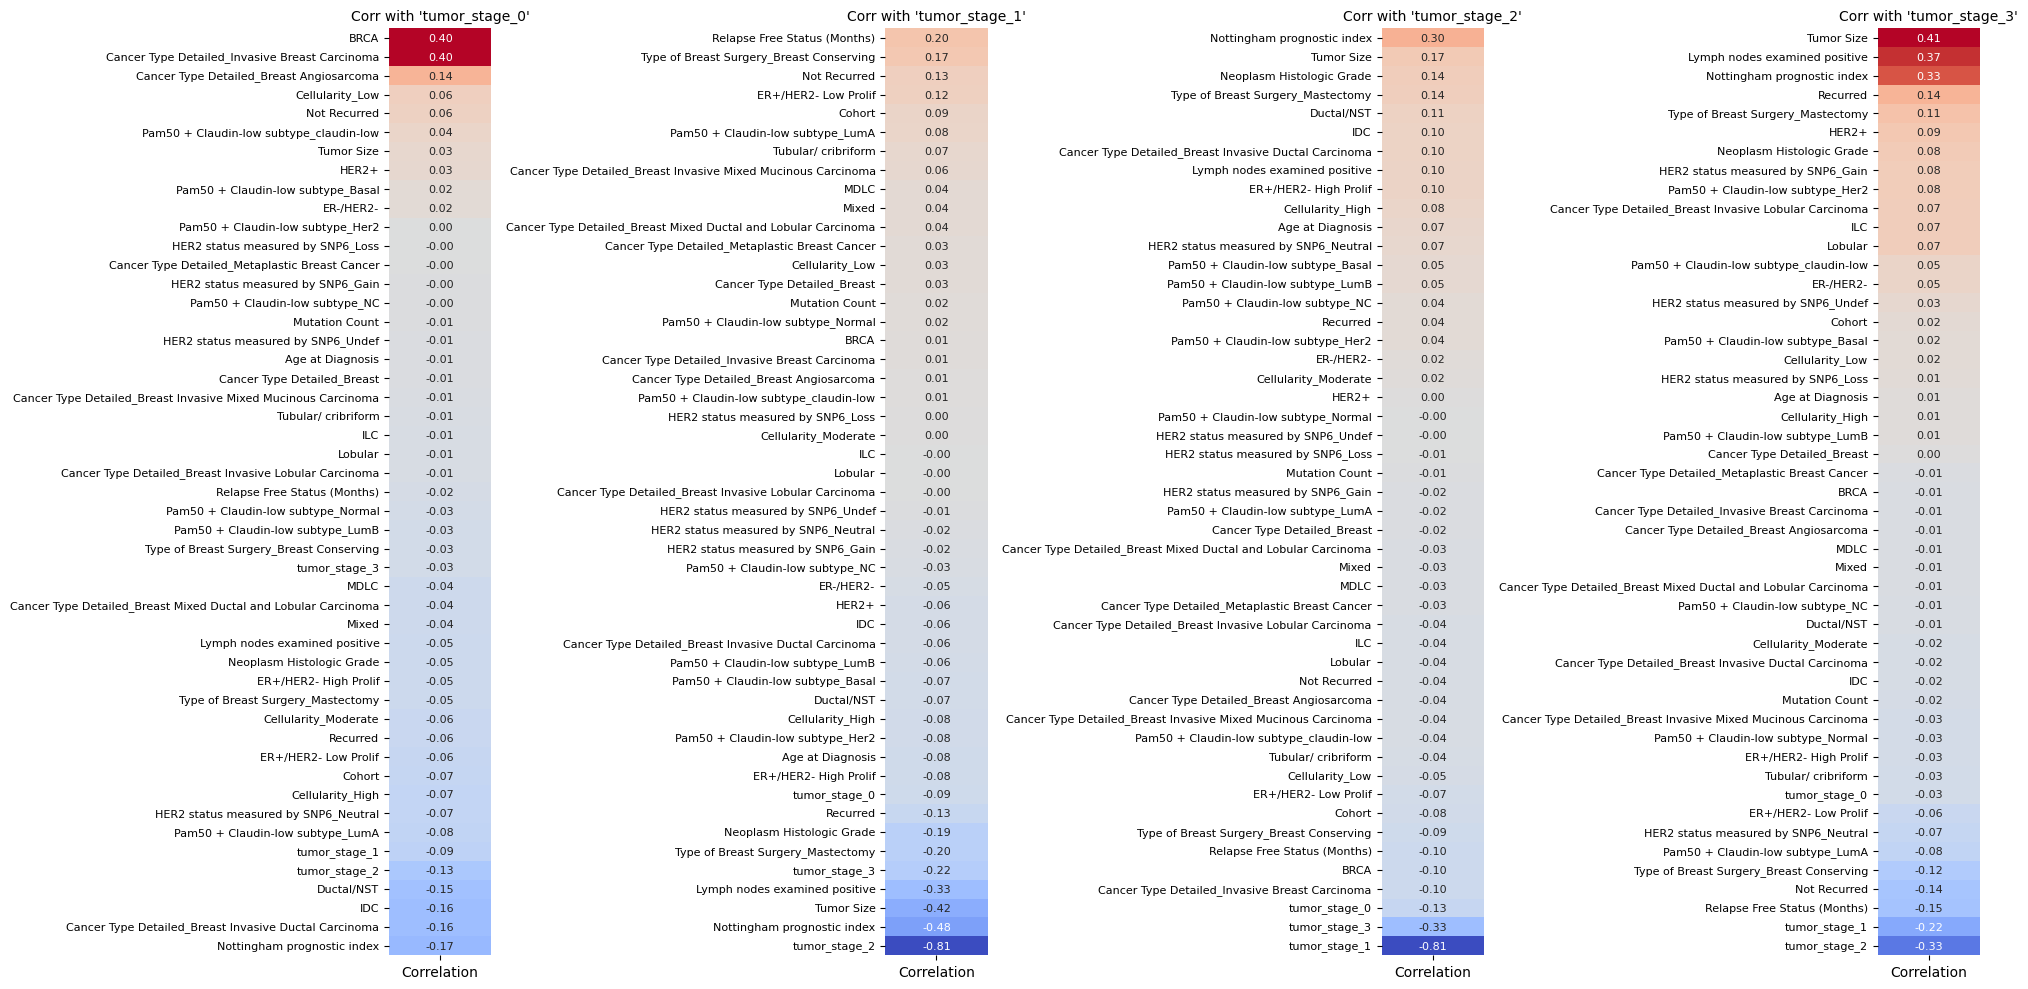

In [61]:
import seaborn as sns


numeric_df = df.select_dtypes(include=['float64', 'int64'])

stages = ['tumor_stage_0','tumor_stage_1','tumor_stage_2','tumor_stage_3']

fig, axes = plt.subplots(1, len(stages), figsize=(5 * len(stages), 10))  # ← Increase height here

for i, stage_col in enumerate(stages):
    corr_series = numeric_df.corr()[stage_col].drop(stage_col)
    corr_df = corr_series.to_frame(name='Correlation').sort_values(by='Correlation', ascending=False)

    sns.heatmap(
        corr_df,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        center=0,
        ax=axes[i],
        cbar=False,
        annot_kws={"size": 8}
    )
    axes[i].set_title(f"Corr with '{stage_col}'", fontsize=10)
    axes[i].tick_params(axis='y', labelrotation=0, labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 1]) 
plt.show()


In [62]:
from sklearn.impute import KNNImputer

feature_0 = ["BRCA", "Cancer Type Detailed_Invasive Breast Carcinoma"]

train_df = df[df["tumor_stage_0"].notnull()]
test_df = df[df["tumor_stage_0"].isnull()]

model = LogisticRegressionCV(cv=7, random_state=0)
X_train = train_df[feature_0]
X_test = test_df[feature_0]
y_train = train_df["tumor_stage_0"]

x_train_train, x_train_test, y_train_train, y_train_test = train_test_split(X_train,y_train,train_size=0.75,random_state=0)

model.fit(x_train_train,y_train_train)

tumor_stage_0_predict = model.predict(x_train_test)

print(accuracy_score(y_train_test,tumor_stage_0_predict))
tumor_stage_0_predict = model.predict(X_test)
df.loc[df['tumor_stage_0'].isna(), 'tumor_stage_0'] = tumor_stage_0_predict

#-------------------------------------------------------------------

feature_1 = ["Nottingham prognostic index", "Tumor Size", "Lymph nodes examined positive"]

train_df = df[df["tumor_stage_1"].notnull()]
test_df = df[df["tumor_stage_1"].isnull()]
imputer = KNNImputer(n_neighbors=20)

X_train = train_df[feature_1].dropna()
X_test_raw = test_df[feature_1]               
X_test = imputer.fit_transform(X_test_raw)    
X_test = pd.DataFrame(X_test, columns=X_test_raw.columns)
y_train = train_df["tumor_stage_1"].loc[X_train.index]

x_train_train, x_train_test, y_train_train, y_train_test = train_test_split(X_train,y_train,train_size=0.75,random_state=0)

model.fit(x_train_train,y_train_train)

tumor_stage_1_predict = model.predict(x_train_test)

print(accuracy_score(y_train_test,tumor_stage_1_predict))
tumor_stage_1_predict = model.predict(X_test)
df.loc[df['tumor_stage_1'].isna(), 'tumor_stage_1'] = tumor_stage_1_predict

#-----------------------------------------------------------------------------------------------------------------------------

feature_2 = ["Nottingham prognostic index", "tumor_stage_1"]

train_df = df[df["tumor_stage_2"].notnull()]
test_df = df[df["tumor_stage_2"].isnull()]
imputer = KNNImputer(n_neighbors=20)

X_train = train_df[feature_2].dropna()
X_test_raw = test_df[feature_2]               
X_test = imputer.fit_transform(X_test_raw)    
X_test = pd.DataFrame(X_test, columns=X_test_raw.columns)
y_train = train_df["tumor_stage_2"].loc[X_train.index]

x_train_train, x_train_test, y_train_train, y_train_test = train_test_split(X_train,y_train,train_size=0.75,random_state=0)

model.fit(x_train_train,y_train_train)

tumor_stage_2_predict = model.predict(x_train_test)

print(accuracy_score(y_train_test,tumor_stage_2_predict))
tumor_stage_2_predict = model.predict(X_test)
df.loc[df['tumor_stage_2'].isna(), 'tumor_stage_2'] = tumor_stage_2_predict

#------------------------------------------------------------------------------------------------------------------------
feature_3 = ["Tumor Size", "Lymph nodes examined positive", "Nottingham prognostic index", "tumor_stage_2"]

train_df = df[df["tumor_stage_3"].notnull()]
test_df = df[df["tumor_stage_3"].isnull()]
imputer = KNNImputer(n_neighbors=20)

X_train = train_df[feature_3].dropna()
X_test_raw = test_df[feature_3]               
X_test = imputer.fit_transform(X_test_raw)    
X_test = pd.DataFrame(X_test, columns=X_test_raw.columns)
y_train = train_df["tumor_stage_3"].loc[X_train.index]

x_train_train, x_train_test, y_train_train, y_train_test = train_test_split(X_train,y_train,train_size=0.75,random_state=0)

model.fit(x_train_train,y_train_train)

tumor_stage_3_predict = model.predict(x_train_test)

print(accuracy_score(y_train_test,tumor_stage_3_predict))
tumor_stage_3_predict = model.predict(X_test)
df.loc[df['tumor_stage_3'].isna(), 'tumor_stage_3'] = tumor_stage_3_predict


0.9888143176733781
0.9175
0.8901601830663616
0.98


Age at Diagnosis                                                    0
Chemotherapy                                                        0
Cohort                                                              0
ER status measured by IHC                                           0
ER Status                                                           0
Neoplasm Histologic Grade                                           0
HER2 Status                                                       529
Hormone Therapy                                                   529
Inferred Menopausal State                                         529
Primary Tumor Laterality                                            0
Lymph nodes examined positive                                       0
Mutation Count                                                      0
Nottingham prognostic index                                         0
Overall Survival Status                                             0
PR Status           

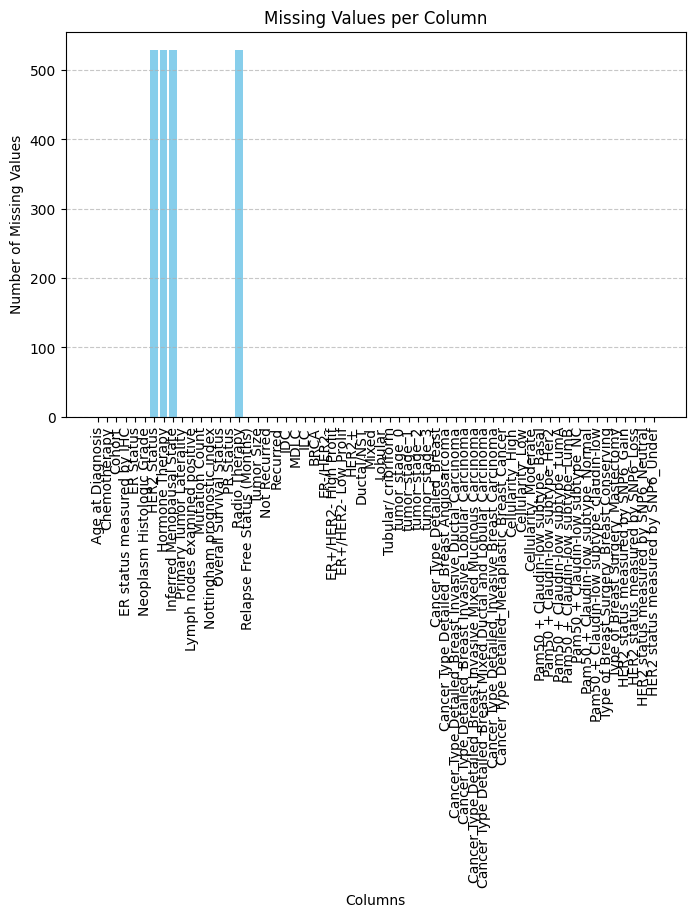

In [63]:
df['Age at Diagnosis'] = imputer.fit_transform(df[['Age at Diagnosis']])
df['Cohort'] = imputer.fit_transform(df[['Cohort']])
df['ER status measured by IHC'] = imputer.fit_transform(df[['ER status measured by IHC']])
df['ER Status'] = imputer.fit_transform(df[['ER Status']])
df['Not Recurred'] = imputer.fit_transform(df[['Not Recurred']])
df['Recurred'] = imputer.fit_transform(df[['Recurred']])
df['Neoplasm Histologic Grade'] = imputer.fit_transform(df[['Neoplasm Histologic Grade']])
df['Mutation Count'] = imputer.fit_transform(df[['Mutation Count']])
df['Relapse Free Status (Months)'] = imputer.fit_transform(df[['Relapse Free Status (Months)']])
df['Tumor Size'] = imputer.fit_transform(df[['Tumor Size']])
df['Lymph nodes examined positive'] = imputer.fit_transform(df[['Lymph nodes examined positive']])
df['Nottingham prognostic index'] = imputer.fit_transform(df[['Nottingham prognostic index']])
df['Overall Survival Status'] = imputer.fit_transform(df[['Overall Survival Status']])

missing_counts = df.isnull().sum()

print(missing_counts)

plt.figure(figsize=(8, 5))
plt.bar(missing_counts.index, missing_counts.values, color='skyblue')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

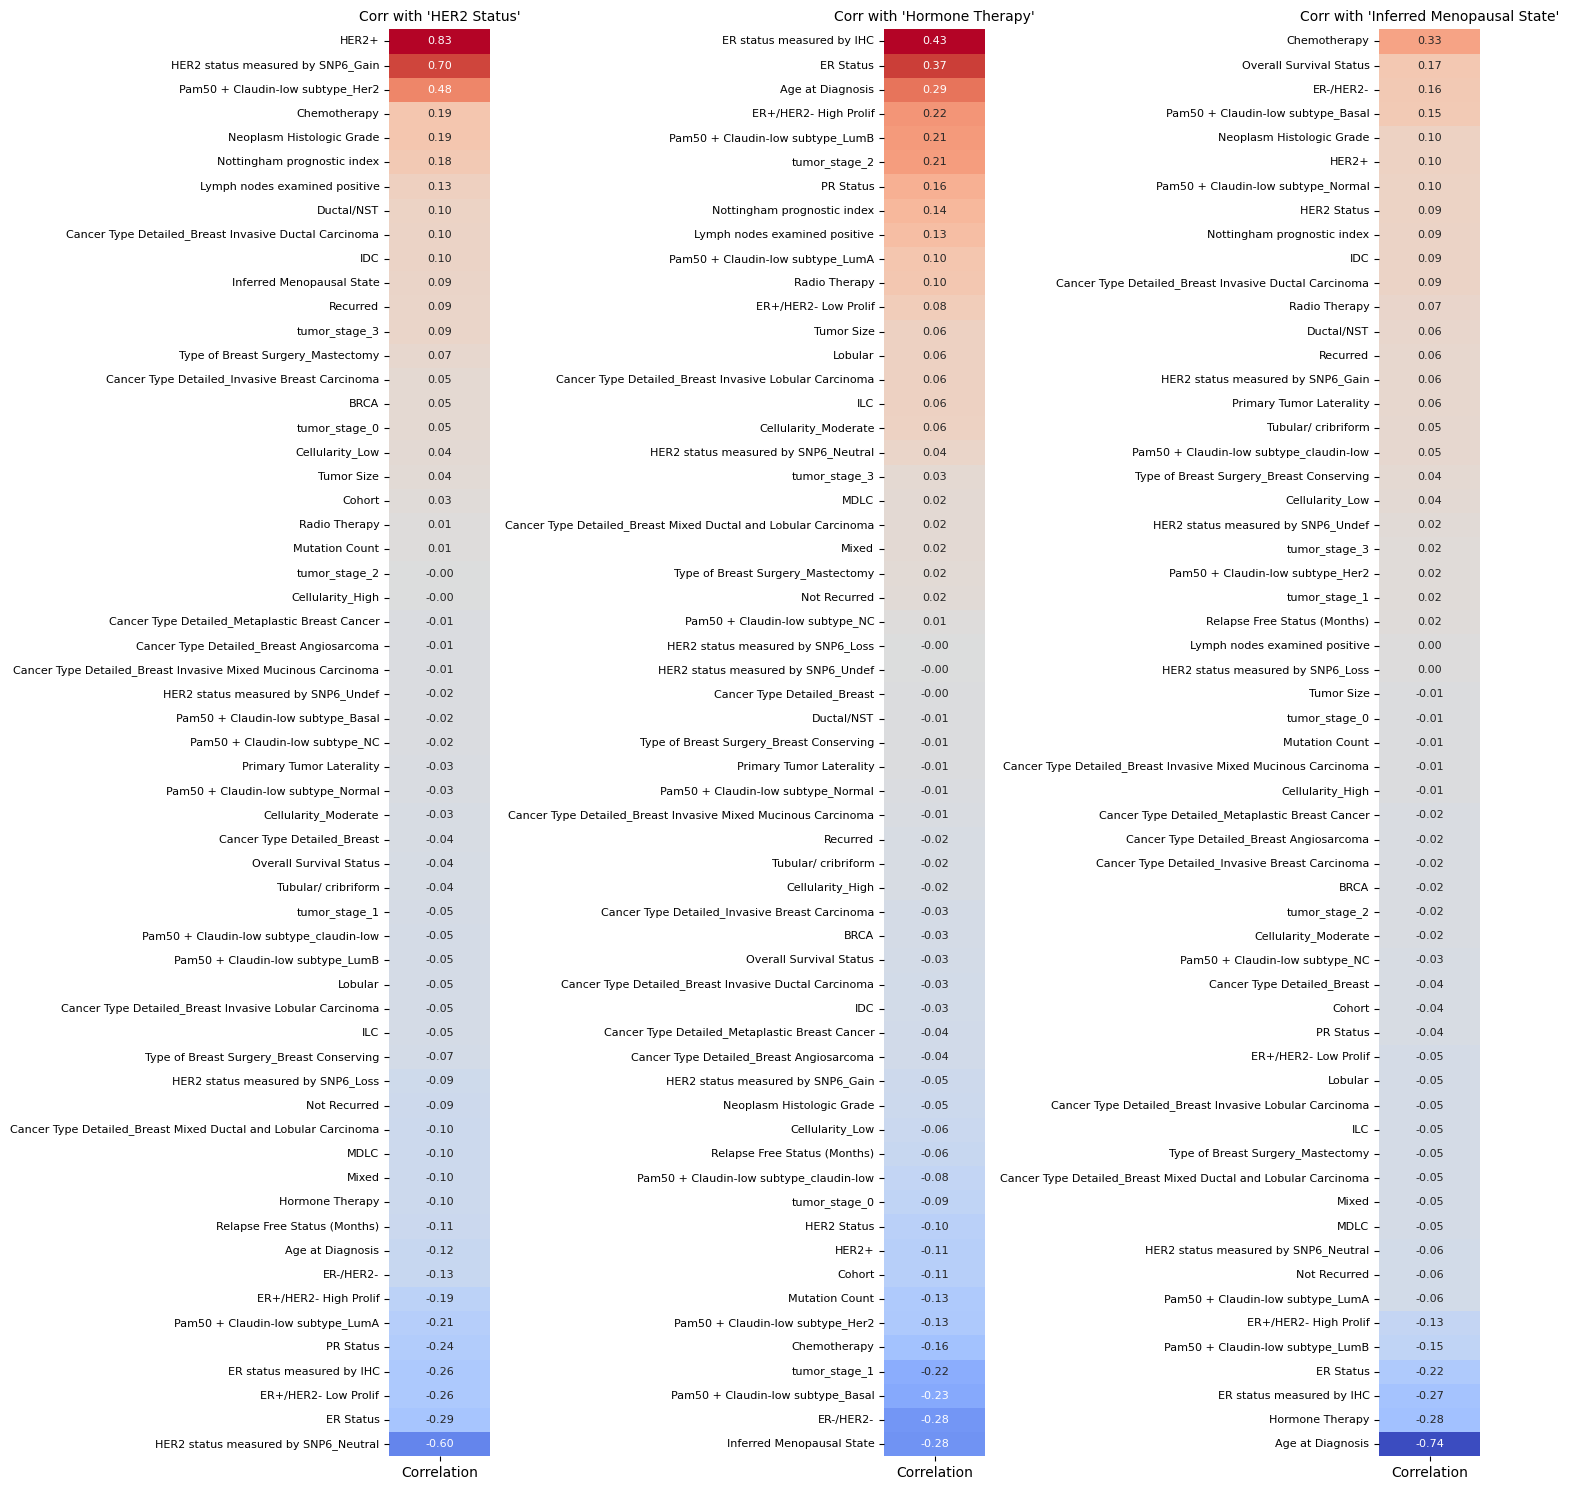

In [64]:
numeric_df = df.select_dtypes(include=['float64', 'int64','object'])

col = ['HER2 Status','Hormone Therapy','Inferred Menopausal State']

fig, axes = plt.subplots(1, len(col), figsize=(5 * len(col), 15))  # ← Increase height here

for i, col in enumerate(col):
    corr_series = numeric_df.corr()[col].drop(col)
    corr_df = corr_series.to_frame(name='Correlation').sort_values(by='Correlation', ascending=False)

    sns.heatmap(
        corr_df,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        center=0,
        ax=axes[i],
        cbar=False,
        annot_kws={"size": 8}
    )
    axes[i].set_title(f"Corr with '{col}'", fontsize=10)
    axes[i].tick_params(axis='y', labelrotation=0, labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 1]) 
plt.show()

In [65]:
from sklearn.impute import SimpleImputer

feature_HER2 = ["HER2 status measured by SNP6_Gain", "HER2+", "Pam50 + Claudin-low subtype_Her2", "HER2 status measured by SNP6_Neutral"]
df.loc[df['HER2 Status'].notnull(), 'HER2 Status'] = df.loc[df['HER2 Status'].notnull(), 'HER2 Status'].astype(int)


train_df = df[df["HER2 Status"].notnull()]
test_df = df[df["HER2 Status"].isnull()]

X_train = train_df[feature_HER2].dropna()
X_test_raw = test_df[feature_HER2]
X_test = imputer.fit_transform(X_test_raw)    
X_test = pd.DataFrame(X_test, columns=X_test_raw.columns)
y_train = train_df["HER2 Status"].loc[X_train.index].astype(int)

x_train_train, x_train_test, y_train_train, y_train_test = train_test_split(X_train,y_train,train_size=0.75,random_state=0)

model.fit(x_train_train,y_train_train)

HER2_predict = model.predict(x_train_test)

print(accuracy_score(y_train_test,HER2_predict))
HER2_predict = model.predict(X_test)
df.loc[df['HER2 Status'].isna(), 'HER2 Status'] = HER2_predict

#------------------------------------------------------------------------------------------------------------------------

feature_Hormone_Therapy = ["ER status measured by IHC", "ER Status", "ER-/HER2-", "Age at Diagnosis"]
df.loc[df['HER2 Status'].notnull(), 'HER2 Status'] = df.loc[df['HER2 Status'].notnull(), 'HER2 Status'].astype(int)


train_df = df[df["Hormone Therapy"].notnull()]
test_df = df[df["Hormone Therapy"].isnull()]

#imputer = SimpleImputer(strategy='mean') 
X_train = train_df[feature_Hormone_Therapy].dropna()
X_test_raw = test_df[feature_Hormone_Therapy]
#print(X_train.head())
print(X_test_raw.head())
imputer = SimpleImputer(strategy='mean')
X_test = imputer.fit_transform(X_test_raw)
X_test = pd.DataFrame(X_test, columns=X_test_raw.columns)
y_train = train_df["Hormone Therapy"].loc[X_train.index].astype(int)

x_train_train, x_train_test, y_train_train, y_train_test = train_test_split(X_train,y_train,train_size=0.75,random_state=0)

model.fit(x_train_train,y_train_train)

Hormone_Therapy_predict = model.predict(x_train_test)

print(accuracy_score(y_train_test,Hormone_Therapy_predict))
Hormone_Therapy_predict = model.predict(X_test_raw)
df.loc[df['Hormone Therapy'].isna(), 'Hormone Therapy'] = Hormone_Therapy_predict

#------------------------------------------------------------------------------------------------------------------------



0.9535353535353536
      ER status measured by IHC  ER Status  ER-/HER2-  Age at Diagnosis
9                           1.0        1.0        0.0              76.0
223                         1.0        1.0        0.0              51.0
226                         1.0        1.0        0.0              76.0
411                         1.0        1.0        0.0              66.0
1680                        1.0        1.0        0.0              65.0
0.7414141414141414


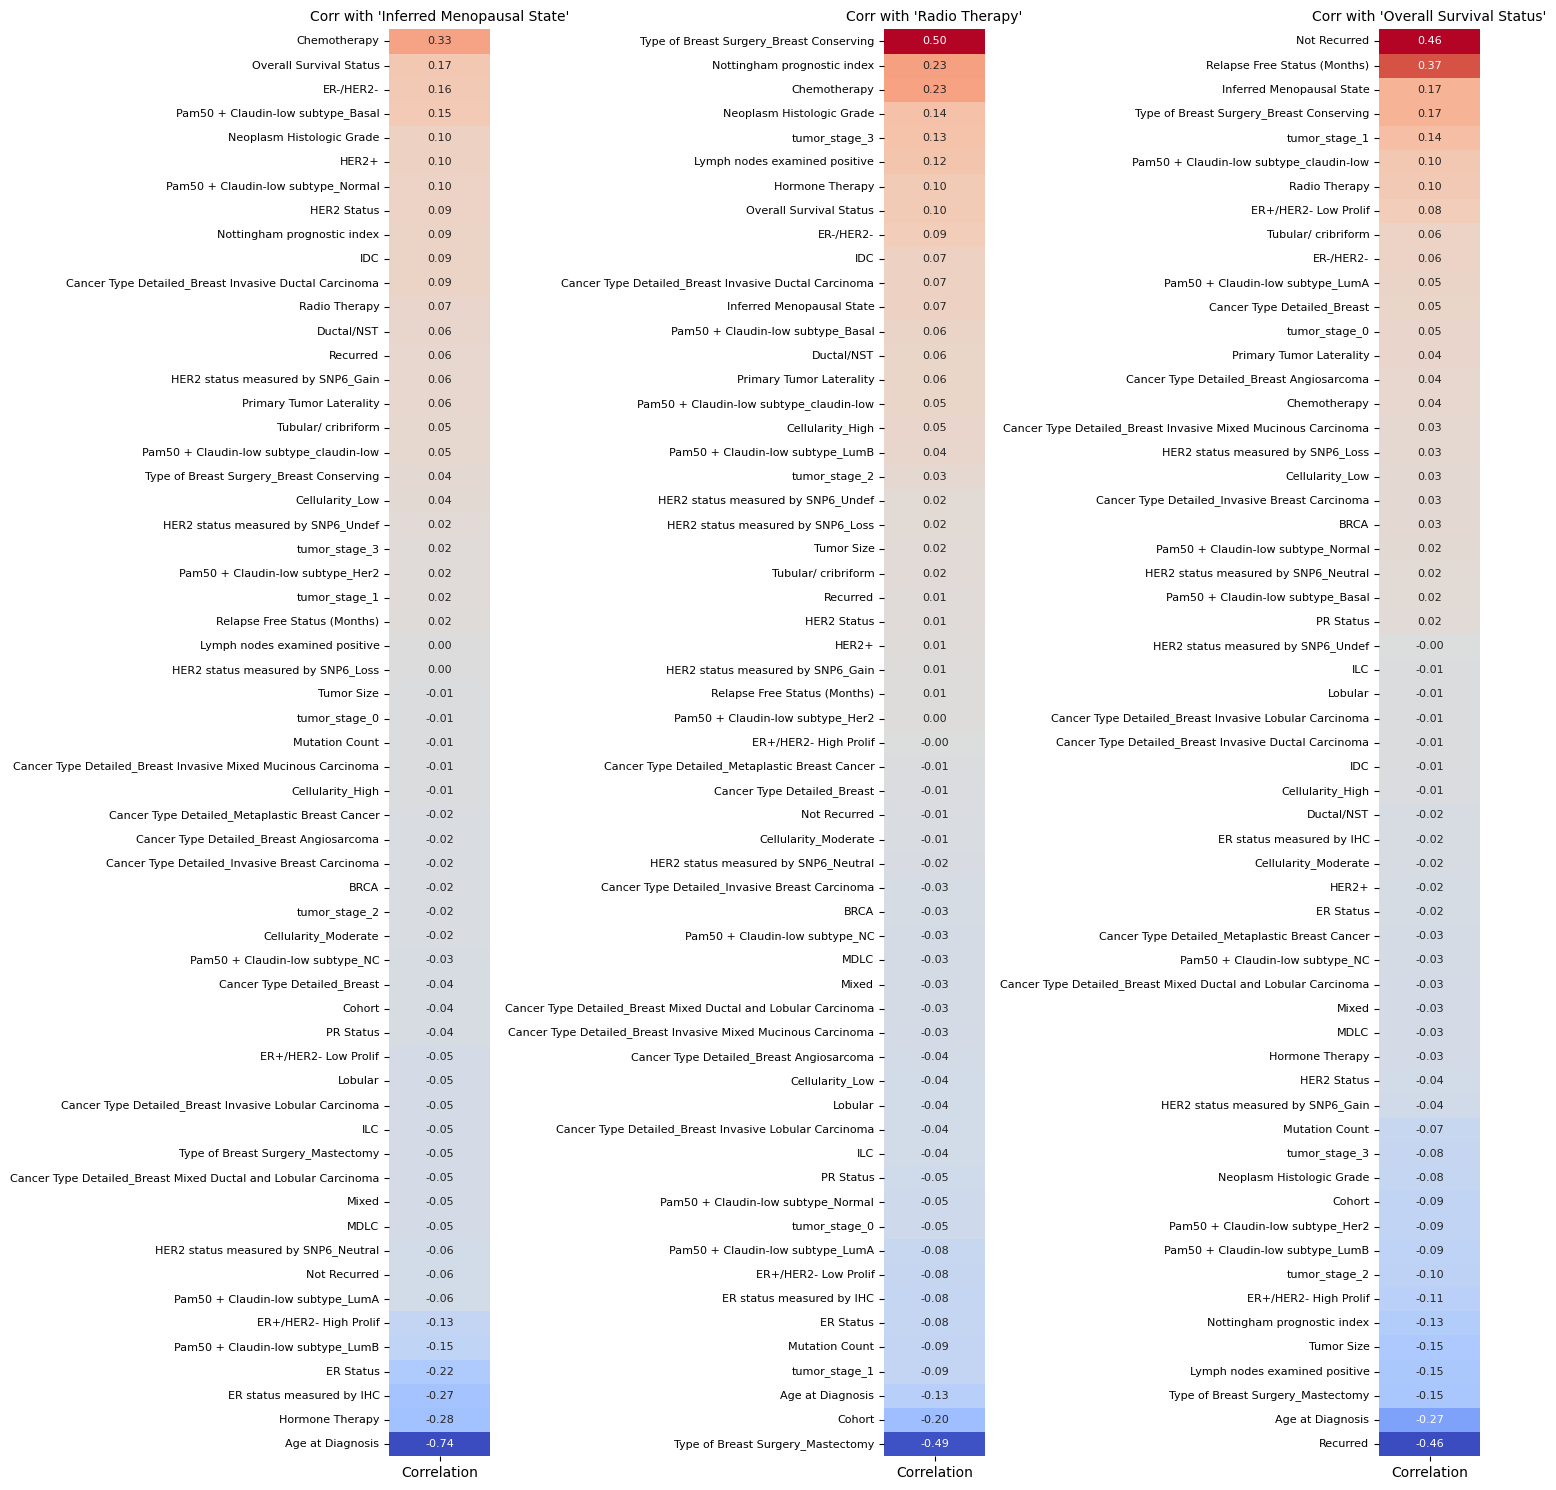

In [66]:
col = ['Inferred Menopausal State','Radio Therapy', 'Overall Survival Status']

fig, axes = plt.subplots(1, len(col), figsize=(5 * len(col), 15))

for i, col in enumerate(col):
    corr_series = numeric_df.corr()[col].drop(col)
    corr_df = corr_series.to_frame(name='Correlation').sort_values(by='Correlation', ascending=False)

    sns.heatmap(
        corr_df,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        center=0,
        ax=axes[i],
        cbar=False,
        annot_kws={"size": 8}
    )
    axes[i].set_title(f"Corr with '{col}'", fontsize=10)
    axes[i].tick_params(axis='y', labelrotation=0, labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 1]) 
plt.show()

In [67]:
#------------------------------------------------------------------------------------------------------------

feature_Inferred = ["Chemotherapy", "Age at Diagnosis", "Hormone Therapy", "ER status measured by IHC"]

train_df = df[df["Inferred Menopausal State"].notnull()]
test_df = df[df["Inferred Menopausal State"].isnull()]

X_train = train_df[feature_Inferred]
X_test = test_df[feature_Inferred]  
y_train = train_df["Inferred Menopausal State"].loc[X_train.index].astype(int)

x_train_train, x_train_test, y_train_train, y_train_test = train_test_split(X_train,y_train,train_size=0.75,random_state=0)

model.fit(x_train_train,y_train_train)

Inferred_predict = model.predict(x_train_test)

print(accuracy_score(y_train_test,Inferred_predict))
Inferred_predict = model.predict(X_test)
df.loc[df['Inferred Menopausal State'].isna(), 'Inferred Menopausal State'] = Inferred_predict

#--------------------------------------------------------------------------------------------------

feature_Radio = ["Type of Breast Surgery_Breast Conserving", "Chemotherapy", "Nottingham prognostic index", "Cohort"]

train_df = df[df["Radio Therapy"].notnull()]
test_df = df[df["Radio Therapy"].isnull()]

X_train = train_df[feature_Radio]
X_test = test_df[feature_Radio]  
y_train = train_df["Radio Therapy"].loc[X_train.index].astype(int)

x_train_train, x_train_test, y_train_train, y_train_test = train_test_split(X_train,y_train,train_size=0.75,random_state=0)

model.fit(x_train_train,y_train_train)

Radio_predict = model.predict(x_train_test)

print(accuracy_score(y_train_test,Radio_predict))
Radio_predict = model.predict(X_test)
df.loc[df['Radio Therapy'].isna(), 'Radio Therapy'] = Radio_predict

df.to_csv("out.csv")


1.0
0.806060606060606


Age at Diagnosis                                                  0
Chemotherapy                                                      0
Cohort                                                            0
ER status measured by IHC                                         0
ER Status                                                         0
Neoplasm Histologic Grade                                         0
HER2 Status                                                       0
Hormone Therapy                                                   0
Inferred Menopausal State                                         0
Primary Tumor Laterality                                          0
Lymph nodes examined positive                                     0
Mutation Count                                                    0
Nottingham prognostic index                                       0
Overall Survival Status                                           0
PR Status                                       

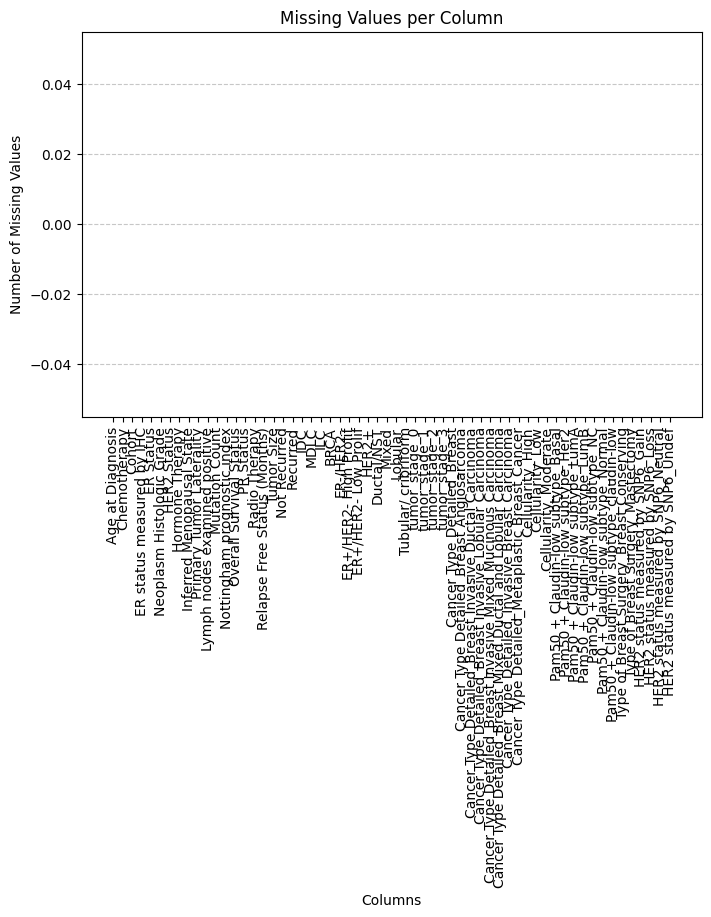

In [68]:
missing_counts = df.isnull().sum()

print(missing_counts)

plt.figure(figsize=(8, 5))
plt.bar(missing_counts.index, missing_counts.values, color='skyblue')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

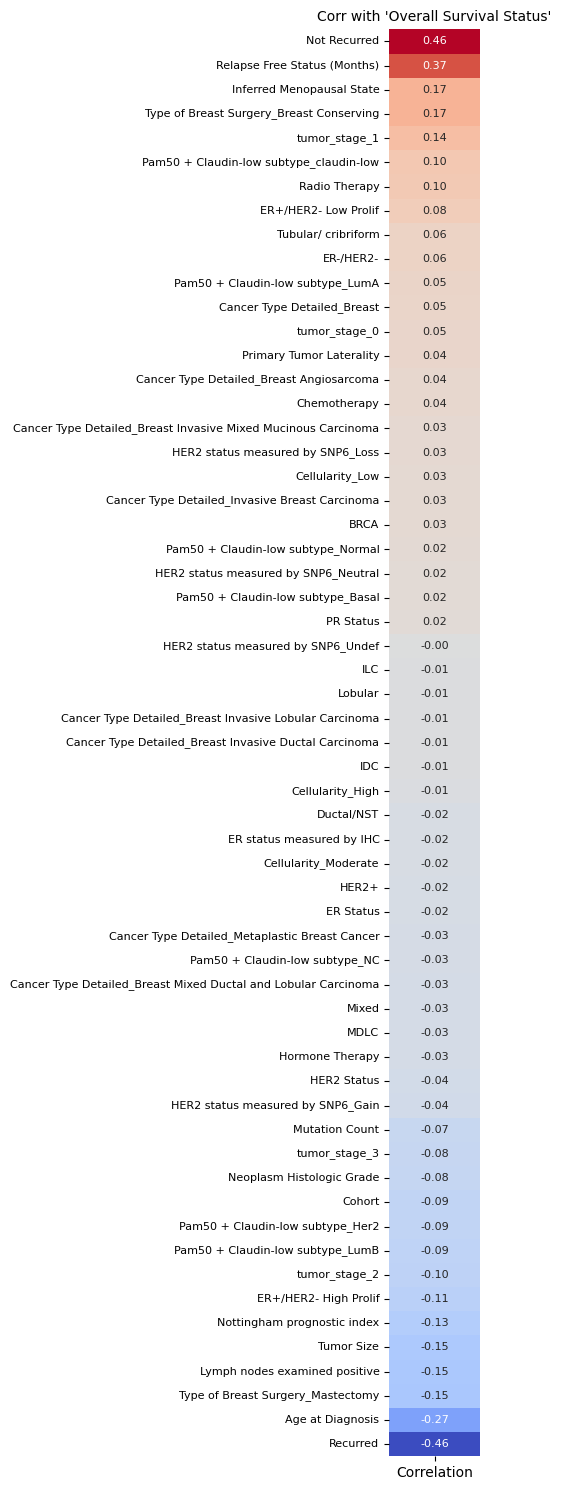

In [69]:
col = ['Overall Survival Status']

fig, axes = plt.subplots(1, len(col), figsize=(5 * len(col), 15))

# Ensure axes is always iterable
if len(col) == 1:
    axes = [axes]

for i, column in enumerate(col):
    corr_series = numeric_df.corr()[column].drop(column)
    corr_df = corr_series.to_frame(name='Correlation').sort_values(by='Correlation', ascending=False)

    sns.heatmap(
        corr_df,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        center=0,
        ax=axes[i],
        cbar=False,
        annot_kws={"size": 8}
    )
    axes[i].set_title(f"Corr with '{column}'", fontsize=10)
    axes[i].tick_params(axis='y', labelrotation=0, labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

features = ["Not Recurred","Recurred","Age at Diagnosis","Type of Breast Surgery_Mastectomy","Lymph nodes examined positive","Tumor Size","Relapse Free Status (Months)","Inferred Menopausal State","Type of Breast Surgery_Breast Conserving"]

x = df[features]
y = df["Overall Survival Status"]
score = []
for i in range(105):
    fmodel = RandomForestClassifier(n_estimators=i+1,random_state=0)

    x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.8,random_state=0)

    fmodel.fit(x_train,y_train.astype(int))

    y_predict = fmodel.predict(x_test)

    score.append(accuracy_score(y_test.astype(int),y_predict))

maxi = max(score)
ind = score.index(maxi)
print(ind+1)

fmodel = RandomForestClassifier(n_estimators=ind+1,class_weight='balanced',random_state=0)

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.8,random_state=0)

fmodel.fit(x_train,y_train.astype(int))

y_predict = fmodel.predict(x_test)
print(accuracy_score(y_test.astype(int),y_predict))

94
0.8401394422310757


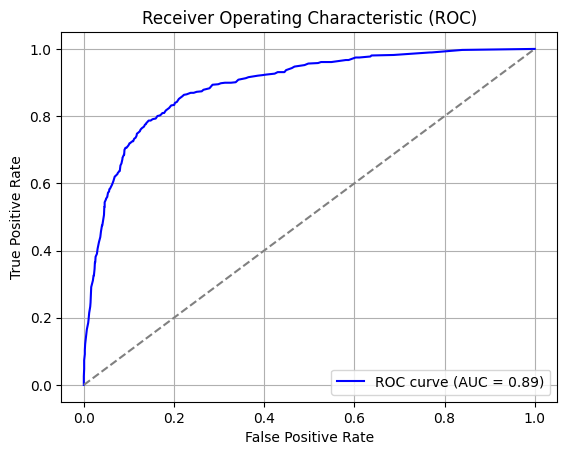

In [71]:
y_prob = fmodel.predict_proba(x_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test.astype(int), y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [72]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score

desired_indices = np.where((tpr >= 0.85))[0]

if len(desired_indices) > 0:
    best_threshold = thresholds[desired_indices[0]] 
    print(f"Threshold meeting desired TPR/FPR: {best_threshold:.2f}")
else:
    print("No threshold meets the desired conditions.")

y_pred_custom = (y_prob >= 0.27).astype(int)
print(confusion_matrix(y_test.astype(int), y_pred_custom))

print(accuracy_score(y_test.astype(int),y_pred_custom))
print(recall_score(y_test.astype(int),y_pred_custom))

Threshold meeting desired TPR/FPR: 0.27
[[1065  277]
 [ 105  561]]
0.8097609561752988
0.8423423423423423


In [73]:
class ThresholdedRandomForest:
    def __init__(self,thresh_hold = 0.5, **kwargs):
        self.thresh_hold = thresh_hold
        self.model = RandomForestClassifier(**kwargs)

    def fit(self,X,y):
        return self.model.fit(X,y)
        
    def predict(self,X_test):
        y_cust_prob = fmodel.predict_proba(X_test)[:, 1]
        return (y_cust_prob >= self.thresh_hold).astype(int)
    
    def predict_proba(self,X_test):
        return fmodel.predict_proba(x_test)[:, 1]
    
    def score(self,X,y):
        from sklearn.metrics import accuracy_score, recall_score
        return accuracy_score(y, self.predict(X)), recall_score(y, self.predict(X))
    

fmod = ThresholdedRandomForest(thresh_hold=0.27,n_estimators=ind+1,class_weight='balanced',random_state=0)

fmod.fit(x_train,y_train.astype(int))

accuracy, recall = fmod.score(x_test,y_test.astype(int))

print(accuracy)
print(recall)

0.8097609561752988
0.8423423423423423


In [74]:
import joblib

joblib.dump(fmod, "thresholded_rf.joblib")

['thresholded_rf.joblib']